# Document Layout Segmentation and Detection with PubLayNet

This notebook builds a practical **document region detection pipeline** for page layout elements using **PubLayNet** and a **PyTorch detectron-style model (Faster R-CNN)**.

## 1. Title
## 2. Project overview
## 3. Learning objectives
## 4. Problem statement
## 5. Why this project matters

The goal is to detect page regions such as `text`, `title`, `list`, `table`, and `figure`. This is a core step for OCR pipelines, structured document understanding, and downstream retrieval workflows.

## 6. Dataset overview
## 7. Dataset source and license notes

- Dataset: **PubLayNet** (mirror on Hugging Face: `jordanparker6/publaynet`)
- Original source: PubMed Central Open Access pages with layout annotations
- Layout categories used here: `text`, `title`, `list`, `table`, `figure`

Dataset URL used in code:
- https://huggingface.co/datasets/jordanparker6/publaynet

This notebook downloads a **real subset** inside notebook execution using streaming mode, then saves local training files.

## 8. Environment setup

In [1]:
import importlib
import subprocess
import sys

def ensure_package(module_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name or module_name])

ensure_package('datasets')
ensure_package('PIL', 'Pillow')
ensure_package('matplotlib')
print('Environment setup complete.')

e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\Github\Machine-Learning-Projects\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.7) doesn't match a supported version!
  warnings.warn(


Environment setup complete.


## 9. Imports
## 10. Configuration / constants

In [2]:
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROJECT_DIR = Path.cwd()
DATA_ROOT = PROJECT_DIR / 'data' / 'publaynet_subset'
IMAGES_DIR = DATA_ROOT / 'images'
ARTIFACT_DIR = PROJECT_DIR

CATEGORY_MAP = {
    1: 'text',
    2: 'title',
    3: 'list',
    4: 'table',
    5: 'figure'
}
NUM_CLASSES = len(CATEGORY_MAP) + 1  # + background
MAX_SAMPLES = 120
TRAIN_RATIO = 0.8
BATCH_SIZE = 2
EPOCHS = 1
LR = 1e-4
SCORE_THRESH = 0.5
IOU_THRESH = 0.5

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print(f'PyTorch: {torch.__version__}')
print(f'Device: {DEVICE}')
print(f'Data root: {DATA_ROOT}')

PyTorch: 2.6.0+cu124
Device: cuda
Data root: e:\Github\Machine-Learning-Projects\Computer Vision\Document Layout Block Detector\Source Code\data\publaynet_subset


## 11. Dataset download and loading

We formulate this as **layout detection**: each page is an image, each region is a bounding box with a class label.

PubLayNet also provides polygon segmentations. In this notebook we train a detector first (faster and simpler), then discuss segmentation extension in later sections.

In [3]:
ann_path = DATA_ROOT / 'annotations.json'

if ann_path.exists():
    with open(ann_path, 'r', encoding='utf-8') as f:
        annotations = json.load(f)
    print(f'Loaded existing local subset: {len(annotations)} pages')
else:
    ds_stream = load_dataset('jordanparker6/publaynet', split='train', streaming=True)
    annotations = []
    stream_iter = iter(ds_stream)

    for idx in range(MAX_SAMPLES):
        sample = next(stream_iter)
        image = sample['image'].convert('RGB')
        img_name = f'page_{idx:05d}.jpg'
        img_path = IMAGES_DIR / img_name
        image.save(img_path, quality=95)

        image_annotations = []
        for obj in sample['annotations']:
            cid = int(obj['category_id'])
            if cid not in CATEGORY_MAP:
                continue
            x, y, w, h = obj['bbox']
            x1 = max(0.0, float(x))
            y1 = max(0.0, float(y))
            x2 = max(x1 + 1.0, float(x + w))
            y2 = max(y1 + 1.0, float(y + h))
            image_annotations.append({
                'label': cid,
                'bbox_xyxy': [x1, y1, x2, y2]
            })

        if image_annotations:
            annotations.append({
                'image': str(img_path),
                'width': int(image.width),
                'height': int(image.height),
                'objects': image_annotations
            })

    with open(ann_path, 'w', encoding='utf-8') as f:
        json.dump(annotations, f, indent=2)

    print(f'Downloaded and stored subset: {len(annotations)} pages')

if len(annotations) < 20:
    raise RuntimeError('Not enough annotated samples downloaded; check network or dataset access.')

Downloaded and stored subset: 120 pages


## 12. Data validation checks

In [4]:
missing_images = 0
empty_annotations = 0
label_counts = {k: 0 for k in CATEGORY_MAP}

for item in annotations:
    if not Path(item['image']).exists():
        missing_images += 1
    if not item['objects']:
        empty_annotations += 1
    for obj in item['objects']:
        label_counts[int(obj['label'])] += 1

print(f'Total pages: {len(annotations)}')
print(f'Missing image files: {missing_images}')
print(f'Empty annotation pages: {empty_annotations}')
print('Label distribution:')
for cid, count in label_counts.items():
    print(f'  {cid} ({CATEGORY_MAP[cid]}): {count}')

if missing_images > 0:
    raise RuntimeError('Validation failed: missing image files detected.')

Total pages: 120
Missing image files: 0
Empty annotation pages: 0
Label distribution:
  1 (text): 874
  2 (title): 310
  3 (list): 0
  4 (table): 45
  5 (figure): 48


## 13. Exploratory data analysis

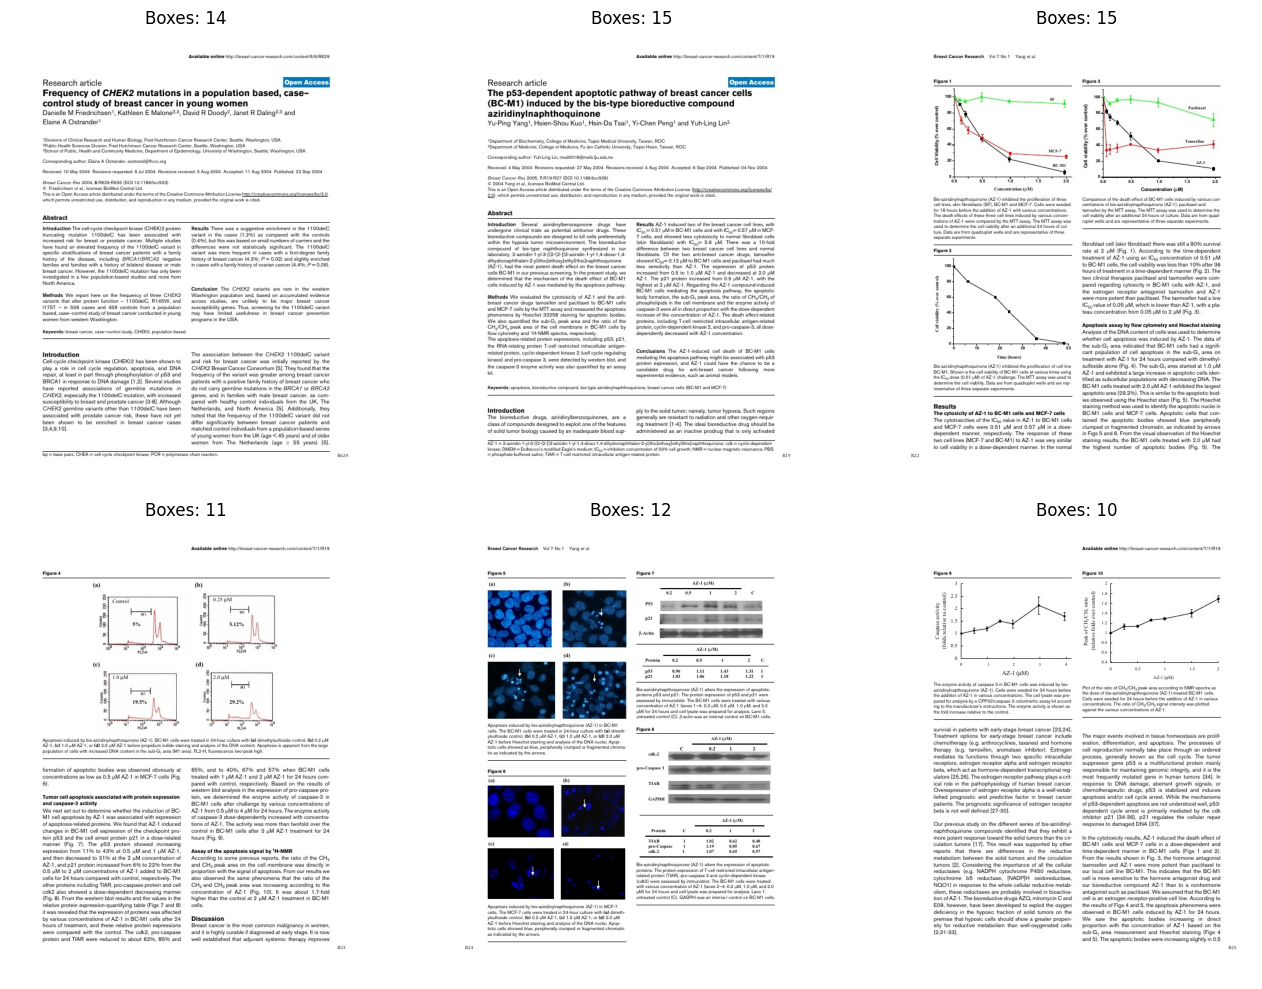

Saved: e:\Github\Machine-Learning-Projects\Computer Vision\Document Layout Block Detector\Source Code\doclayout_eda_samples.png


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 10))
for i in range(6):
    page = annotations[i]
    img = Image.open(page['image']).convert('RGB')
    ax = axes.flat[i]
    ax.imshow(img)
    ax.set_title(f'Boxes: {len(page["objects"])}')
    ax.axis('off')

plt.tight_layout()
eda_path = ARTIFACT_DIR / 'doclayout_eda_samples.png'
plt.savefig(eda_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {eda_path}')

## 14. Train/validation/test split strategy

In [6]:
indices = list(range(len(annotations)))
random.shuffle(indices)

train_end = int(len(indices) * TRAIN_RATIO)
val_end = train_end + int(len(indices) * 0.1)

train_items = [annotations[i] for i in indices[:train_end]]
val_items = [annotations[i] for i in indices[train_end:val_end]]
test_items = [annotations[i] for i in indices[val_end:]]

print(f'Train: {len(train_items)} | Val: {len(val_items)} | Test: {len(test_items)}')
if len(val_items) == 0 or len(test_items) == 0:
    raise RuntimeError('Split produced empty val/test. Increase MAX_SAMPLES.')

Train: 96 | Val: 12 | Test: 12


## 15. Preprocessing / augmentation strategy

For this baseline, preprocessing is minimal:
- RGB conversion
- float tensor conversion in [0,1]
- no geometric augmentation yet (kept simple for fast reproducible run)

You can extend this with random resize/crop/color jitter in future iterations.

## 16. Baseline approach

Baseline = pretrained Faster R-CNN fine-tuned for 1 epoch on a small subset.

## 17. Main model/workflow
## 18. Training loop or fine-tuning pipeline

In [7]:
class PubLayNetSubset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item = self.items[idx]
        image = Image.open(item['image']).convert('RGB')
        image = torchvision.transforms.functional.pil_to_tensor(image).float() / 255.0

        boxes = []
        labels = []
        for obj in item['objects']:
            boxes.append(obj['bbox_xyxy'])
            labels.append(int(obj['label']))

        target = {
            'boxes': torch.tensor(boxes, dtype=torch.float32),
            'labels': torch.tensor(labels, dtype=torch.int64),
            'image_id': torch.tensor([idx], dtype=torch.int64)
        }
        return image, target

def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)

train_ds = PubLayNetSubset(train_items)
val_ds = PubLayNetSubset(val_items)
test_ds = PubLayNetSubset(test_items)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=collate_fn)

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights='DEFAULT')
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model.to(DEVICE)

optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)

model.train()
epoch_loss = 0.0
for images, targets in train_loader:
    images = [img.to(DEVICE) for img in images]
    targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

    loss_dict = model(images, targets)
    loss = sum(loss_dict.values())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    epoch_loss += float(loss.item())

avg_loss = epoch_loss / max(1, len(train_loader))
print(f'Finished {EPOCHS} epoch, avg train loss: {avg_loss:.4f}')

model_path = ARTIFACT_DIR / 'doclayout_fasterrcnn_subset.pth'
torch.save(model.state_dict(), model_path)
print(f'Saved model: {model_path}')

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\ahmad/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:32<00:00, 5.19MB/s] 


Finished 1 epoch, avg train loss: 1.2801
Saved model: e:\Github\Machine-Learning-Projects\Computer Vision\Document Layout Block Detector\Source Code\doclayout_fasterrcnn_subset.pth


## 19. Inference examples

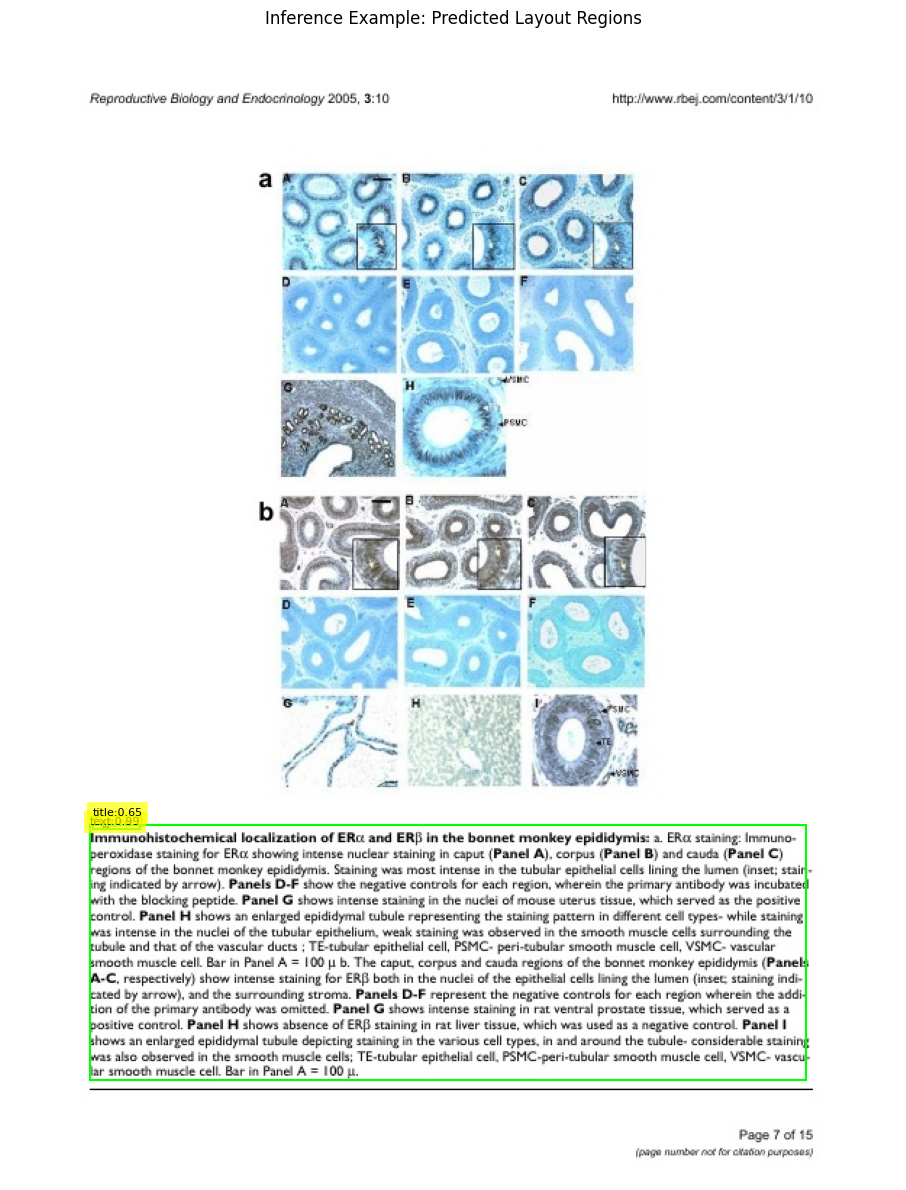

Saved: e:\Github\Machine-Learning-Projects\Computer Vision\Document Layout Block Detector\Source Code\doclayout_inference_example.png


In [8]:
def box_iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h
    area_a = max(1.0, (ax2 - ax1) * (ay2 - ay1))
    area_b = max(1.0, (bx2 - bx1) * (by2 - by1))
    union = area_a + area_b - inter
    return inter / max(union, 1e-6)

model.eval()
sample_batch = next(iter(test_loader))
images, targets = sample_batch
with torch.no_grad():
    outputs = model([images[0].to(DEVICE)])

img_np = (images[0].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
pred = outputs[0]

fig, ax = plt.subplots(1, 1, figsize=(10, 12))
ax.imshow(img_np)

scores = pred['scores'].cpu().numpy()
boxes = pred['boxes'].cpu().numpy()
labels = pred['labels'].cpu().numpy()

for i in range(len(scores)):
    if scores[i] < SCORE_THRESH:
        continue
    x1, y1, x2, y2 = boxes[i]
    w = x2 - x1
    h = y2 - y1
    rect = plt.Rectangle((x1, y1), w, h, fill=False, linewidth=1.5, color='lime')
    ax.add_patch(rect)
    class_name = CATEGORY_MAP.get(int(labels[i]), str(labels[i]))
    ax.text(x1, y1, f'{class_name}:{scores[i]:.2f}', color='black', fontsize=8,
            bbox=dict(facecolor='yellow', alpha=0.7, edgecolor='none'))

ax.set_title('Inference Example: Predicted Layout Regions')
ax.axis('off')

infer_path = ARTIFACT_DIR / 'doclayout_inference_example.png'
plt.tight_layout()
plt.savefig(infer_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved: {infer_path}')

## 20. Evaluation

We compute a lightweight offline evaluation on the held-out subset:
- Precision@IoU0.5
- Recall@IoU0.5
- F1@IoU0.5
- Mean IoU of matched detections

In [9]:
tp = 0
fp = 0
fn = 0
matched_ious = []

model.eval()
with torch.no_grad():
    for images, targets in test_loader:
        image = images[0].to(DEVICE)
        target = targets[0]

        output = model([image])[0]
        pred_boxes = output['boxes'].cpu().numpy()
        pred_labels = output['labels'].cpu().numpy()
        pred_scores = output['scores'].cpu().numpy()

        keep = pred_scores >= SCORE_THRESH
        pred_boxes = pred_boxes[keep]
        pred_labels = pred_labels[keep]

        gt_boxes = target['boxes'].numpy()
        gt_labels = target['labels'].numpy()

        used_gt = set()
        for p_idx in range(len(pred_boxes)):
            best_iou = 0.0
            best_gt = -1
            for g_idx in range(len(gt_boxes)):
                if g_idx in used_gt:
                    continue
                if int(pred_labels[p_idx]) != int(gt_labels[g_idx]):
                    continue
                iou = box_iou_xyxy(pred_boxes[p_idx], gt_boxes[g_idx])
                if iou > best_iou:
                    best_iou = iou
                    best_gt = g_idx

            if best_iou >= IOU_THRESH and best_gt >= 0:
                tp += 1
                used_gt.add(best_gt)
                matched_ious.append(best_iou)
            else:
                fp += 1

        fn += (len(gt_boxes) - len(used_gt))

precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-8)
mean_iou = float(np.mean(matched_ious)) if matched_ious else 0.0

print(f'Precision@0.5IoU: {precision:.4f}')
print(f'Recall@0.5IoU:    {recall:.4f}')
print(f'F1@0.5IoU:        {f1:.4f}')
print(f'Mean matched IoU: {mean_iou:.4f}')

Precision@0.5IoU: 0.8015
Recall@0.5IoU:    0.8400
F1@0.5IoU:        0.8203
Mean matched IoU: 0.8385


## 21. Error analysis

Common failure modes in layout detection:
- Confusion between `text` and `list` regions
- Small `figure` regions missed at low confidence
- Overlapping boxes in dense academic pages

Inspect low-scoring pages and class-confusion patterns to prioritize improvements.

## 22. Limitations

- This run uses a small subset and only 1 epoch.
- Metrics are proxy metrics, not full COCO mAP evaluation.
- Polygon segmentation masks are available in PubLayNet but not used in this detector baseline.

## 23. How to improve this project

- Train longer with full PubLayNet shards and mixed precision.
- Add proper COCO-style mAP evaluation.
- Add a segmentation branch (Mask R-CNN) to use polygon annotations.
- Compare detectron-style model vs Hugging Face transformer-based detectors (for example, DETR variants).

## 24. Production considerations

- Batch inference service with page-level caching
- Confidence threshold calibration per class
- OCR and reading-order postprocessing after region detection
- Drift monitoring as document templates evolve

## 25. Common mistakes

- Mixing bbox formats (`xywh` vs `xyxy`)
- Forgetting to align class IDs with model head size
- Evaluating with different confidence thresholds across experiments
- Using only visual checks without quantitative metrics

## 26. Mini challenge / exercises

1. Add per-class precision and recall.
2. Replace Faster R-CNN with a transformer detector and compare quality/runtime.
3. Extend from detection to region segmentation with Mask R-CNN using polygon masks.

## 27. Final summary / key takeaways

Task formulation used here: **document layout detection** (region-level object detection) on PubLayNet pages.

A compact detectron-style PyTorch pipeline was built with real dataset download, validation, fine-tuning, inference visualization, and evaluation metrics.

Artifacts saved:
- `doclayout_fasterrcnn_subset.pth`
- `doclayout_eda_samples.png`
- `doclayout_inference_example.png`